# Data Models

## Logistic Regression Model

In [6]:
import pandas as pd

df = pd.read_csv("../data/startup_success_dataset.csv")

In [7]:
# Logistic Regression Pipeline on Startup Dataset

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import pandas as pd


# 1. Encode categorical features
# Convert categorical variables into numerical form for ML compatibility

data = df.copy()

categorical_cols = ['sector', 'founder_background', 'investor_type']

for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])


# Encode target variable AND keep class names for interpretation
le_target = LabelEncoder()
y = le_target.fit_transform(data['outcome'])
class_names = le_target.classes_

X = data.drop('outcome', axis=1)


# 2. Train/Test split
# We use 80% training and 20% testing with stratification to keep class balance

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


# 3. Logistic Regression model
pipe_LR = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=5000))
])

pipe_LR.fit(X_train, y_train)
y_pred = pipe_LR.predict(X_test)


# 4. Confusion Matrix (with class names)
cm_LR = confusion_matrix(y_test, y_pred)

print("Confusion Matrix (Startup Logistic Regression):")
print(pd.DataFrame(
    cm_LR,
    index=[f"Actual {name}" for name in class_names],
    columns=[f"Pred {name}" for name in class_names]
))


# 5. Classification Report (with class names)
print("\nClassification Report (Startup Logistic Regression):")
print(classification_report(
    y_test,
    y_pred,
    target_names=class_names
))


# 6. Metrics Summary (clean table format)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
accuracy = accuracy_score(y_test, y_pred)

results_LR = {
    'Startup Logistic Regression': {
        'accuracy': round(accuracy, 4),
        'precision': round(precision, 4),
        'recall': round(recall, 4),
        'f1_score': round(f1, 4)
    }
}

print("\nStored Metrics (Startup Logistic Regression):")
print(pd.DataFrame(results_LR).T)

Confusion Matrix (Startup Logistic Regression):
                    Pred Acquisition  Pred Failure  Pred IPO
Actual Acquisition              5577          2832        58
Actual Failure                  1915          9206         1
Actual IPO                       301             1       109

Classification Report (Startup Logistic Regression):
              precision    recall  f1-score   support

 Acquisition       0.72      0.66      0.69      8467
     Failure       0.76      0.83      0.79     11122
         IPO       0.65      0.27      0.38       411

    accuracy                           0.74     20000
   macro avg       0.71      0.58      0.62     20000
weighted avg       0.74      0.74      0.74     20000


Stored Metrics (Startup Logistic Regression):
                             accuracy  precision  recall  f1_score
Startup Logistic Regression    0.7446     0.7415  0.7446    0.7402


## Random Forest Model

In [8]:
# Random Forest Model on Startup Dataset

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import pandas as pd


# 1. Train/Test split already done (reuse X_train, X_test, y_train, y_test)


# 2. Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)


# 3. Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix (Random Forest):")
print(pd.DataFrame(
    cm_rf,
    index=[f"Actual {name}" for name in class_names],
    columns=[f"Pred {name}" for name in class_names]
))


# 4. Classification Report
print("\nClassification Report (Random Forest):")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=class_names
))


# 5. Metrics
precision = precision_score(y_test, y_pred_rf, average='weighted')
recall = recall_score(y_test, y_pred_rf, average='weighted')
accuracy = accuracy_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf, average='weighted')

results_RF = {
    'Random Forest': {
        'accuracy': round(accuracy, 4),
        'precision': round(precision, 4),
        'recall': round(recall, 4),
        'f1_score': round(f1, 4)
    }
}

print("\nStored Metrics (Random Forest):")
print(pd.DataFrame(results_RF).T)

Confusion Matrix (Random Forest):
                    Pred Acquisition  Pred Failure  Pred IPO
Actual Acquisition              5569          2869        29
Actual Failure                  2009          9113         0
Actual IPO                       345             1        65

Classification Report (Random Forest):
              precision    recall  f1-score   support

 Acquisition       0.70      0.66      0.68      8467
     Failure       0.76      0.82      0.79     11122
         IPO       0.69      0.16      0.26       411

    accuracy                           0.74     20000
   macro avg       0.72      0.55      0.58     20000
weighted avg       0.73      0.74      0.73     20000


Stored Metrics (Random Forest):
               accuracy  precision  recall  f1_score
Random Forest    0.7373     0.7347  0.7373    0.7317


## Model Performance (Table)

In [9]:
# Model Comparison Table
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [0.7446, 0.7373],
    "Precision (weighted)": [0.7415, 0.7347],
    "Recall (weighted)": [0.7446, 0.7373],
    "F1 Score (weighted)": [0.7402, 0.7317]
})

comparison

,Model,Accuracy,Precision (weighted),Recall (weighted),F1 Score (weighted)
0,Logistic Regression,0.7446,0.7415,0.7446,0.7402
1,Random Forest,0.7373,0.7347,0.7373,0.7317


## Model Performance Comparison (Bar Chart)

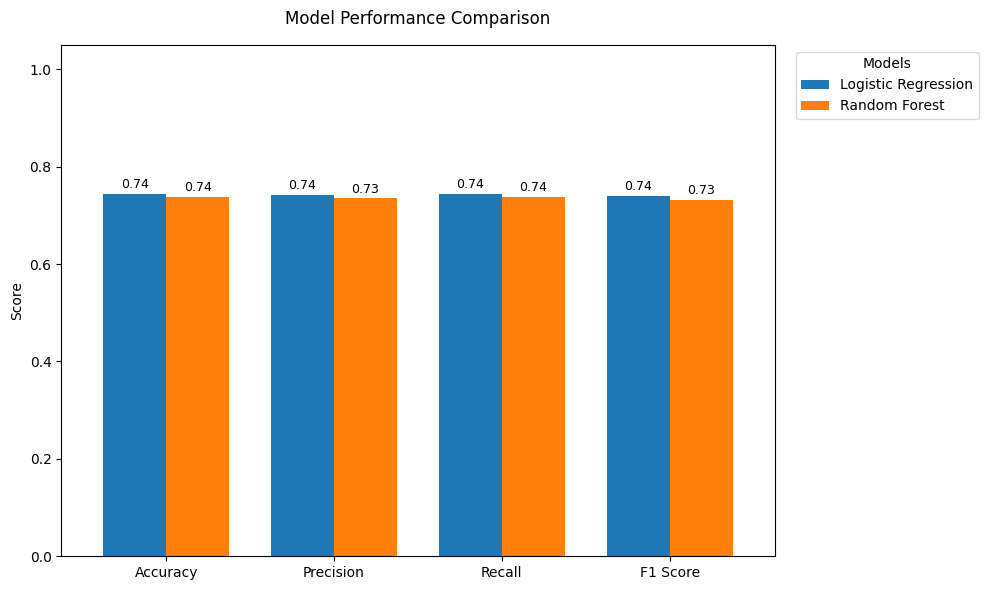

In [9]:
# Bar Chart comparing metrics across Models
import pandas as pd
import matplotlib.pyplot as plt

comparison = pd.DataFrame({
    "Logistic Regression": {
        "Accuracy": 0.7446,
        "Precision": 0.7415,
        "Recall": 0.7446,
        "F1 Score": 0.7402
    },
    "Random Forest": {
        "Accuracy": 0.7373,
        "Precision": 0.7347,
        "Recall": 0.7373,
        "F1 Score": 0.7317
    }
})

comparison = comparison.round(4)

ax = comparison.plot(kind="bar", figsize=(10,6), width=0.75)

# Value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=9, padding=2)

plt.title("Model Performance Comparison", pad=15)
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(title="Models", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Feature Importance Comparison (Bar Chart)

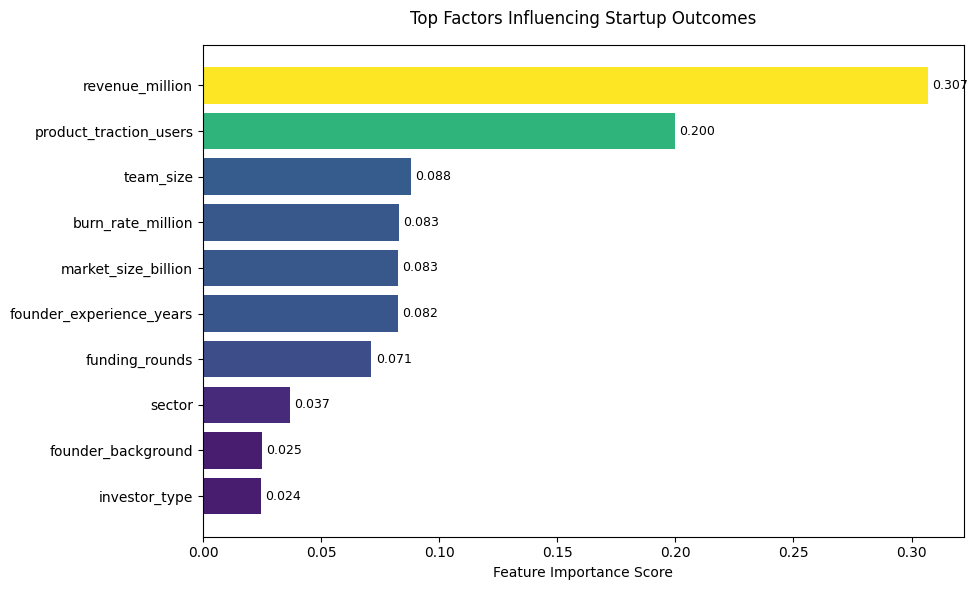

In [14]:
# Get feature importance from Random Forest
import matplotlib.pyplot as plt
import pandas as pd

importances = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=True)

# Top 10 features only
top_features = feature_importance.tail(10)

plt.figure(figsize=(10,6))

colors = plt.cm.viridis(top_features["Importance"] / top_features["Importance"].max())

bars = plt.barh(
    top_features["Feature"],
    top_features["Importance"],
    color=colors
)

# Add value labels
plt.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)

plt.title("Top Factors Influencing Startup Outcomes", pad=15)
plt.xlabel("Feature Importance Score")

# Fix cutoff issue
plt.subplots_adjust(left=0.40)

plt.tight_layout()
plt.show()

## SHAP Beeswarm Plot

100%|===================| 599/600 [03:16<00:00]        

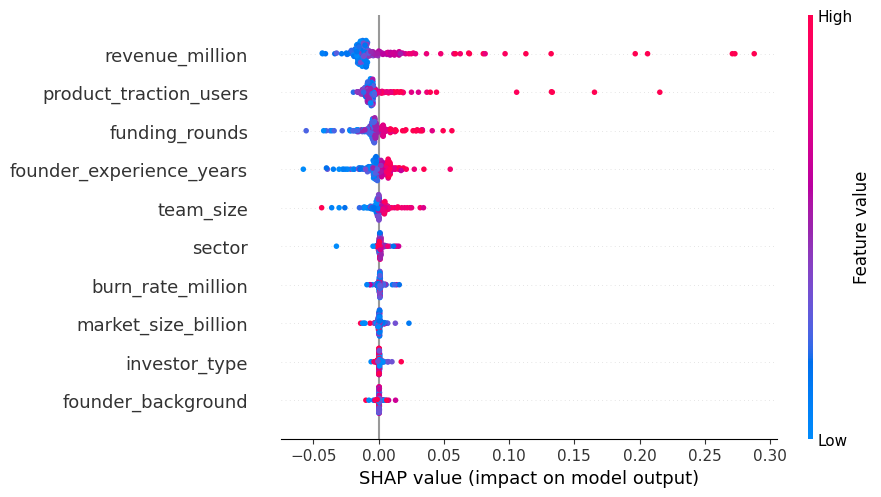

In [20]:
# SHAP Beeswarm Plot for IPO (rare class)
import shap

X_shap = X_test.sample(200, random_state=42)

explainer = shap.Explainer(rf_model, X_train)
shap_values = explainer(X_shap)

class_idx = 2  # IPO

shap.plots.beeswarm(
    shap_values[..., class_idx],
    max_display=10,
    show=True
)